# Parkinson's Disease Gene Expression Analysis
## Notebook 3: Preprocessing

Dataset: GSE99039 (GEO)

Flow of this notebook:
- Load labeled expression data from Notebook 02
- Remove AFFX control probes
- Filter out low variance genes
- Normalize the data
- Save the clean dataset 

Author: Athanasiadou Maria

## Step 1 - Load the labeled data
The labeled expression file created in the Notebook 02 contains only the IPD and Control samples, with the label column attached.

In [20]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
# Load the labeled expression data saved in Notebook 02
data = pd.read_csv("../data/labeled_expression.csv.gz", index_col=0, compression="gzip")

print(f"Data loaded successfully.")

Data loaded successfully.


## Step 2: Remove AFFX probes
AFFX are technical control probes placed on the microarray chip by the manufacturer (Affymetrix)
to check that the experiment ran correctly. They need to be removed before any further analysis.

In [22]:
# Separate the label column before we start modifying the expression data
labels = data["label"]
expr = data.drop(columns="label")

print(f"Expression matrix shape before cleaning: {expr.shape}")

Expression matrix shape before cleaning: (438, 54675)


In [23]:
# Count how many AFFX probes exist before removing them
n_affx = expr.columns.str.startswith("AFFX").sum()
print(f"Number of AFFX probes found: {n_affx}")

# Remove all columns whose name starts with 'AFFX'
affx_cols = expr.columns[expr.columns.str.startswith("AFFX")]
expr = expr.drop(columns=affx_cols)

print(f"Expression matrix shape after removing AFFX probes: {expr.shape}")

Number of AFFX probes found: 62
Expression matrix shape after removing AFFX probes: (438, 54613)


## Step 3 - Filter low variance genes 
Only the top 25% most variable genes will be kept in order to remove enough low-variance noise and to filter enough genes without risking throwing away many biologically important ones.

In [24]:
# Keep only the top 25% most variable genes
gene_variance = expr.var(axis=0)
expr = expr.loc[:, gene_variance > gene_variance.quantile(0.75)]

print(f"Shape after variance filtering: {expr.shape}")

Shape after variance filtering: (438, 13653)


## Step 4 - Normalize the data
Normalizing puts every gene on the same scale so the model judges them purely on how much they vary across patients, not on the size of their numbers.

In [25]:
from sklearn.preprocessing import StandardScaler

# Create the scaler object
scaler = StandardScaler()

# Fit the scaler to our data and transform it
expr_scaled = scaler.fit_transform(expr)

# Convert back to a DataFrame
expr_scaled = pd.DataFrame(expr_scaled, index=expr.index, columns=expr.columns)

print(f"Scaling complete.")
print(f"Shape: {expr_scaled.shape}")
print(f"\nMean of first gene (should be ~0): {expr_scaled.iloc[:, 0].mean():.6f}")
print(f"Std of first gene  (should be ~1): {expr_scaled.iloc[:, 0].std():.6f}")

Scaling complete.
Shape: (438, 13653)

Mean of first gene (should be ~0): -0.000000
Std of first gene  (should be ~1): 1.001144


## Step 5 - Visual Check after normalization
After standardization the distribution should be centered around 0.

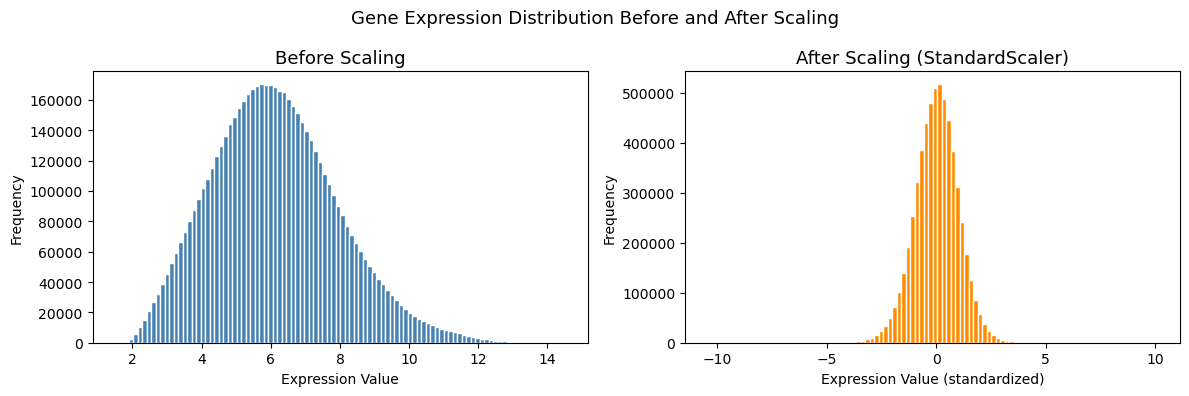

In [26]:
# Plot distribution before and after scaling side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before scaling — use the filtered but unscaled data
axes[0].hist(expr.values.flatten(), bins=100, color="steelblue", edgecolor= "white")
axes[0].set_title("Before Scaling", fontsize=13)
axes[0].set_xlabel("Expression Value")
axes[0].set_ylabel("Frequency")

# After scaling
axes[1].hist(expr_scaled.values.flatten(), bins=100, color="darkorange", edgecolor= "white")
axes[1].set_title("After Scaling (StandardScaler)", fontsize=13)
axes[1].set_xlabel("Expression Value (standardized)")
axes[1].set_ylabel("Frequency")

plt.suptitle("Gene Expression Distribution Before and After Scaling", fontsize=13)
plt.tight_layout()
plt.show()

## Step 6 - Save the clean dataset

In [27]:
# Reattach the label column to the scaled expression data
final_data = expr_scaled.copy()
final_data["label"] = labels.values

print(f"Final dataset shape: {final_data.shape}")

Final dataset shape: (438, 13654)


In [28]:
# Save the clean dataset
final_data.to_csv("../data/preprocessed_expression.csv.gz", compression="gzip")
print("Saved: ../data/preprocessed_expression.csv.gz")

# Save the list of filtered genes 
gene_list = pd.Series(expr_scaled.columns, name="probe_id")
gene_list.to_csv("../data/selected_genes.csv", index=False)
print(f"Saved: ../data/selected_genes.csv  ({len(gene_list)} genes)")

Saved: ../data/preprocessed_expression.csv.gz
Saved: ../data/selected_genes.csv  (13653 genes)
